# 03 — Amplitude Damping: Model Exploration & γ Validation

This notebook develops the **amplitude damping channel** from first principles and validates the γ derivation used throughout this project.

**Road map**

| Section | Content |
|---|---|
| 1 | Imports and path setup |
| 2 | Kraus operator definition and completeness check |
| 3 | Deriving γ from T₁ relaxation — continuous curve + hardware overlay |
| 4 | Multi-step density matrix decay — numerical vs. analytical |
| 5 | Bloch sphere convergence — 3-D trajectory visualization |
| 6 | PennyLane cross-validation |
| 7 | Platform summary table |

**Noise model recap:**

$$\gamma = 1 - e^{-t_{\mathrm{gate}} / T_1}$$

where $t_{\mathrm{gate}}$ and $T_1$ share the same units (nanoseconds throughout).

**Kraus representation of the amplitude damping channel:**

$$\mathcal{E}(\rho) = K_0 \rho K_0^\dagger + K_1 \rho K_1^\dagger$$

$$K_0 = \begin{pmatrix} 1 & 0 \\ 0 & \sqrt{1-\gamma} \end{pmatrix}, \qquad K_1 = \begin{pmatrix} 0 & \sqrt{\gamma} \\ 0 & 0 \end{pmatrix}$$

In [1]:
import sys
import os

# Add src/ to path so we can import project packages
sys.path.insert(0, os.path.join("..", "src"))

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D          # noqa: F401 — registers 3d projection
import pennylane as qml

from noise.amplitude_damping import (
    gamma_from_specs,
    kraus_operators,
    apply_channel,
    apply_channel_k_times,
    analytical_rho11,
    analytical_rho01_magnitude,
)

# ── shared style constants (matches notebook 02) ─────────────────────────
DARK_RC = {
    "figure.facecolor": "#0d0d0d",
    "axes.facecolor":   "#0d0d0d",
    "axes.edgecolor":   "#333333",
    "axes.labelcolor":  "#cccccc",
    "xtick.color":      "#888888",
    "ytick.color":      "#888888",
    "grid.color":       "#1e1e1e",
    "text.color":       "#cccccc",
    "legend.facecolor": "#141414",
    "legend.edgecolor": "#333333",
}
PALETTE = ["#00b4d8", "#f77f00", "#06d6a0", "#ef476f"]   # IBM / Google / Intel / IonQ

FIGURES_DIR = os.path.join("..", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Imports OK.  PennyLane", qml.__version__)

/Users/devinlucas/Desktop/CS480A8/CS480A8-Final-Project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Imports OK.  PennyLane 0.38.0


## 1. Kraus Operators

The amplitude damping channel has two Kraus operators.  $K_0$ preserves $|0\rangle$ and partially preserves $|1\rangle$; $K_1$ transfers population from $|1\rangle$ to $|0\rangle$.

**Completeness relation** (trace-preserving requirement):

$$K_0^\dagger K_0 + K_1^\dagger K_1 = I$$

We verify this numerically for a representative γ value, then show what the channel does to the two computational basis states.

In [2]:
gamma_demo = 0.01   # representative small γ
K0, K1 = kraus_operators(gamma_demo)

print(f"γ = {gamma_demo}\n")
print("K0 =")
print(K0.real)
print("\nK1 =")
print(K1.real)

# ── Completeness check ────────────────────────────────────────────────────
completeness = K0.conj().T @ K0 + K1.conj().T @ K1
assert np.allclose(completeness, np.eye(2)), "Completeness relation violated!"
print("\nCompleteness  K0†K0 + K1†K1 =")
print(completeness.real)
print("\nAll entries within numerical tolerance of identity: PASS")

γ = 0.01

K0 =
[[1.         0.        ]
 [0.         0.99498744]]

K1 =
[[0.  0.1]
 [0.  0. ]]

Completeness  K0†K0 + K1†K1 =
[[1. 0.]
 [0. 1.]]

All entries within numerical tolerance of identity: PASS


In [3]:
# ── Effect on basis states ────────────────────────────────────────────────
rho_0 = np.array([[1, 0], [0, 0]], dtype=complex)   # |0><0|
rho_1 = np.array([[0, 0], [0, 1]], dtype=complex)   # |1><1|

rho_0_out = apply_channel(rho_0, gamma_demo)
rho_1_out = apply_channel(rho_1, gamma_demo)

print("Input |0><0|  →  output:")
print(rho_0_out.real)
print()
print(f"Input |1><1|  →  output  (γ = {gamma_demo}):")
print(rho_1_out.real)
print()
print(f"  rho_out[0,0] = {rho_1_out[0,0].real:.6f}  (should equal γ = {gamma_demo})")
print(f"  rho_out[1,1] = {rho_1_out[1,1].real:.6f}  (should equal 1-γ = {1-gamma_demo})")

Input |0><0|  →  output:
[[1. 0.]
 [0. 0.]]

Input |1><1|  →  output  (γ = 0.01):
[[0.01 0.  ]
 [0.   0.99]]

  rho_out[0,0] = 0.010000  (should equal γ = 0.01)
  rho_out[1,1] = 0.990000  (should equal 1-γ = 0.99)


## 2. Deriving γ from T₁ Relaxation

A qubit in state $|1\rangle$ decays to $|0\rangle$ with a characteristic time $T_1$ (energy relaxation).  
After an exposure time $t$, the probability that the qubit has **not** decayed is $e^{-t/T_1}$, so the probability it **has** decayed is:

$$\gamma(t) = 1 - e^{-t / T_1}$$

Setting $t = t_{\mathrm{gate}}$ gives the per-gate damping probability used in the simulation.

**Key observations**
- For $t \ll T_1$: $\gamma \approx t/T_1$ (linear regime, all platforms live here)
- Higher $T_1/t_{\mathrm{gate}}$ ratios place the platform further left on the curve (lower γ, less noise)
- IonQ's extreme $T_1$ pushes its γ orders of magnitude below the superconducting platforms

Saved: ../results/figures/gamma_derivation_curve.png


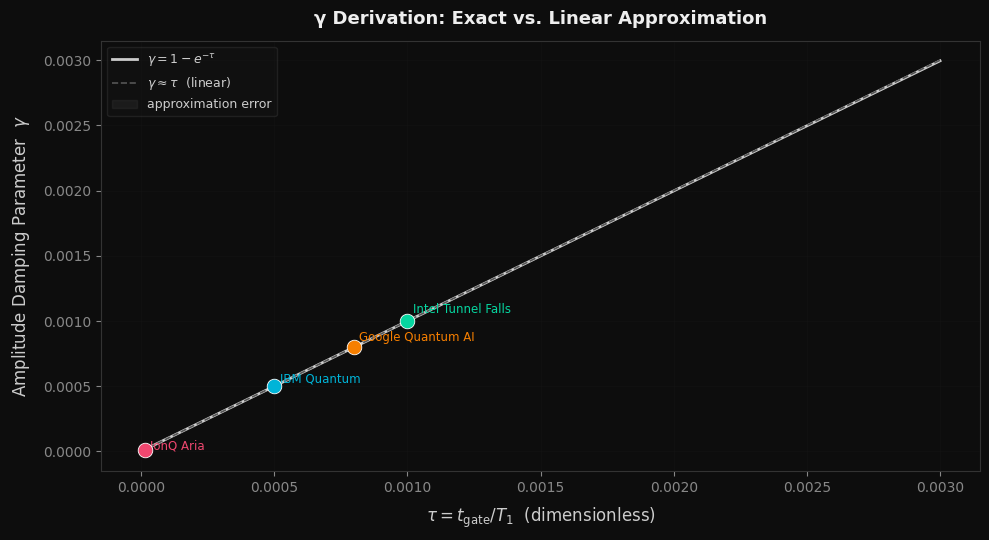

In [4]:
# ── Load hardware specs and compute γ ─────────────────────────────────────
csv_path = os.path.join("..", "data", "hardware_specs", "hardware_specs.csv")
df = pd.read_csv(csv_path)
df["T1_ns"]  = df["T1_us"] * 1_000
df["ratio"]  = df["T1_ns"] / df["t_gate_ns"]
df["gamma"]  = df.apply(lambda r: gamma_from_specs(r["T1_us"], r["t_gate_ns"]), axis=1)
df["tau"]    = df["t_gate_ns"] / df["T1_ns"]    # dimensionless t_gate / T1

# ── Continuous γ(τ) curve ─────────────────────────────────────────────────
tau_range = np.linspace(0, 0.003, 2_000)
gamma_curve = 1.0 - np.exp(-tau_range)
gamma_linear = tau_range                         # first-order Taylor series

with plt.rc_context(DARK_RC):
    fig, ax = plt.subplots(figsize=(10, 5.5))
    fig.patch.set_facecolor("#0d0d0d")

    # Exact curve
    ax.plot(tau_range, gamma_curve,
            color="#cccccc", linewidth=2.0, label=r"$\gamma = 1 - e^{-\tau}$", zorder=2)

    # Linear approximation
    ax.plot(tau_range, gamma_linear,
            color="#555555", linewidth=1.2, linestyle="--",
            label=r"$\gamma \approx \tau$  (linear)", zorder=2)

    # Shaded region between exact and linear (error of approximation)
    ax.fill_between(tau_range, gamma_linear, gamma_curve,
                    color="#cccccc", alpha=0.06, label="approximation error")

    # Platform scatter points
    for i, (_, row) in enumerate(df.iterrows()):
        ax.scatter(row["tau"], row["gamma"],
                   color=PALETTE[i], s=110, zorder=5,
                   edgecolors="white", linewidths=0.6)
        label_text = row["platform"].split("(")[0].strip()
        offset_x = 0.00002
        offset_y = row["gamma"] * 0.06
        ax.annotate(
            label_text,
            xy=(row["tau"], row["gamma"]),
            xytext=(row["tau"] + offset_x, row["gamma"] + offset_y),
            color=PALETTE[i], fontsize=8.5,
            arrowprops=dict(arrowstyle="-", color=PALETTE[i], lw=0.7),
        )

    ax.set_xlabel(r"$\tau = t_{\mathrm{gate}} / T_1$  (dimensionless)", fontsize=12, labelpad=8)
    ax.set_ylabel(r"Amplitude Damping Parameter  $\gamma$", fontsize=12, labelpad=8)
    ax.set_title("γ Derivation: Exact vs. Linear Approximation",
                 fontsize=13, fontweight="bold", color="#eeeeee", pad=12)
    ax.legend(fontsize=9, framealpha=0.5, loc="upper left")
    ax.grid(True, alpha=0.25, linewidth=0.6)

    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "gamma_derivation_curve.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
    print(f"Saved: {out}")
    plt.show()

## 3. Multi-Step Decay — Numerical vs. Analytical

Applying the channel $k$ times to the pure excited state $|1\rangle\langle 1|$ gives a closed-form prediction for the diagonal elements:

$$\rho_{11}(k) = \rho_{11}(0) \cdot (1-\gamma)^k, \qquad \rho_{00}(k) = 1 - \rho_{11}(k)$$

The off-diagonal magnitude decays as:

$$|\rho_{01}(k)| = |\rho_{01}(0)| \cdot (1-\gamma)^{k/2}$$

This is the **core validation**: if our Kraus implementation is correct, the numerical matrix trace will exactly match these expressions.  We test on an equatorial superposition state $|+\rangle = \tfrac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$, which has $\rho_{11}(0) = 0.5$ and $|\rho_{01}(0)| = 0.5$.

Saved: ../results/figures/amplitude_damping_decay.png


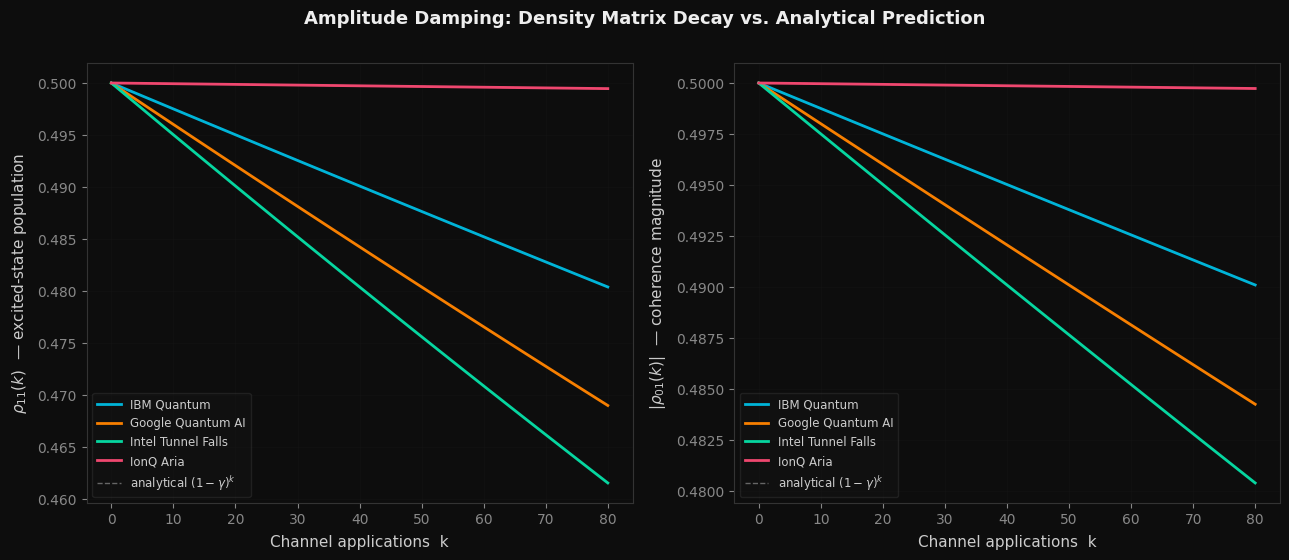

In [5]:
K_STEPS = 80

# Initial state: |+><+| (equatorial superposition)
rho_plus = np.array([[0.5, 0.5],
                     [0.5, 0.5]], dtype=complex)

platform_data = {}
for i, row in df.iterrows():
    gamma_p = row["gamma"]
    rho11_num, rho01_num = [], []
    rho = rho_plus.copy()
    for _ in range(K_STEPS + 1):
        rho11_num.append(rho[1, 1].real)
        rho01_num.append(abs(rho[0, 1]))
        rho = apply_channel(rho, gamma_p)
    platform_data[row["platform"]] = {
        "gamma": gamma_p,
        "rho11_num": np.array(rho11_num),
        "rho01_num": np.array(rho01_num),
    }

ks = np.arange(K_STEPS + 1)

with plt.rc_context(DARK_RC):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.patch.set_facecolor("#0d0d0d")
    fig.suptitle("Amplitude Damping: Density Matrix Decay vs. Analytical Prediction",
                 fontsize=13, fontweight="bold", color="#eeeeee", y=1.01)

    for ax, (ylabel, key, ana_fn) in zip(
        axes,
        [
            (r"$\rho_{11}(k)$  — excited-state population", "rho11_num",
             lambda g, k: analytical_rho11(0.5, g, k)),
            (r"$|\rho_{01}(k)|$  — coherence magnitude", "rho01_num",
             lambda g, k: analytical_rho01_magnitude(0.5, g, k)),
        ],
    ):
        for color, (name, pdata) in zip(PALETTE, platform_data.items()):
            gamma_p = pdata["gamma"]
            numerical = pdata[key]
            analytical = np.array([ana_fn(gamma_p, int(k)) for k in ks])

            label_short = name.split("(")[0].strip()
            ax.plot(ks, numerical,
                    color=color, linewidth=2.0, label=label_short, zorder=3)
            ax.plot(ks, analytical,
                    color=color, linewidth=1.0, linestyle="--", alpha=0.55, zorder=2)

        # Legend entry for the dashed style
        ax.plot([], [], color="#666666", linewidth=1.0, linestyle="--",
                label="analytical $(1-\\gamma)^k$")

        ax.set_xlabel("Channel applications  k", fontsize=11, labelpad=6)
        ax.set_ylabel(ylabel, fontsize=11, labelpad=6)
        ax.legend(fontsize=8.5, framealpha=0.5)
        ax.grid(True, alpha=0.25, linewidth=0.6)

    plt.tight_layout()
    out = os.path.join(FIGURES_DIR, "amplitude_damping_decay.png")
    plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
    print(f"Saved: {out}")
    plt.show()

In [6]:
# ── Numerical validation assertion ────────────────────────────────────────
print("Validation: numerical channel vs. closed-form\n")
for color, (name, pdata) in zip(PALETTE, platform_data.items()):
    gamma_p = pdata["gamma"]
    for k in [0, 1, 10, 50, 80]:
        num_val  = pdata["rho11_num"][k]
        ana_val  = analytical_rho11(0.5, gamma_p, k)
        residual = abs(num_val - ana_val)
        assert residual < 1e-12, f"Mismatch at k={k} for {name}: {residual:.2e}"
    print(f"  {name[:35]:<35}  γ = {gamma_p:.2e}   PASS")

print("\nAll platforms: numerical == analytical to < 1e-12")

Validation: numerical channel vs. closed-form

  IBM Quantum (Eagle)                  γ = 5.00e-04   PASS
  Google Quantum AI (Sycamore)         γ = 8.00e-04   PASS
  Intel Tunnel Falls (spin)            γ = 1.00e-03   PASS
  IonQ Aria (trapped ion)              γ = 1.35e-05   PASS

All platforms: numerical == analytical to < 1e-12


## 4. Bloch Sphere Convergence

Every qubit state $\rho$ maps to a point inside the unit sphere via the Bloch vector:

$$\vec{r} = \bigl(\, 2\,\mathrm{Re}(\rho_{01}),\; 2\,\mathrm{Im}(\rho_{01}),\; \rho_{00} - \rho_{11} \bigr)$$

The amplitude damping channel shrinks both the equatorial radius and the $z$-component toward $+1$ (the north pole, $|0\rangle$).  Starting from $|+\rangle$ on the equator, each platform's trajectory spirals inward at a rate set by $\gamma$.

Saved: ../results/figures/bloch_convergence.png


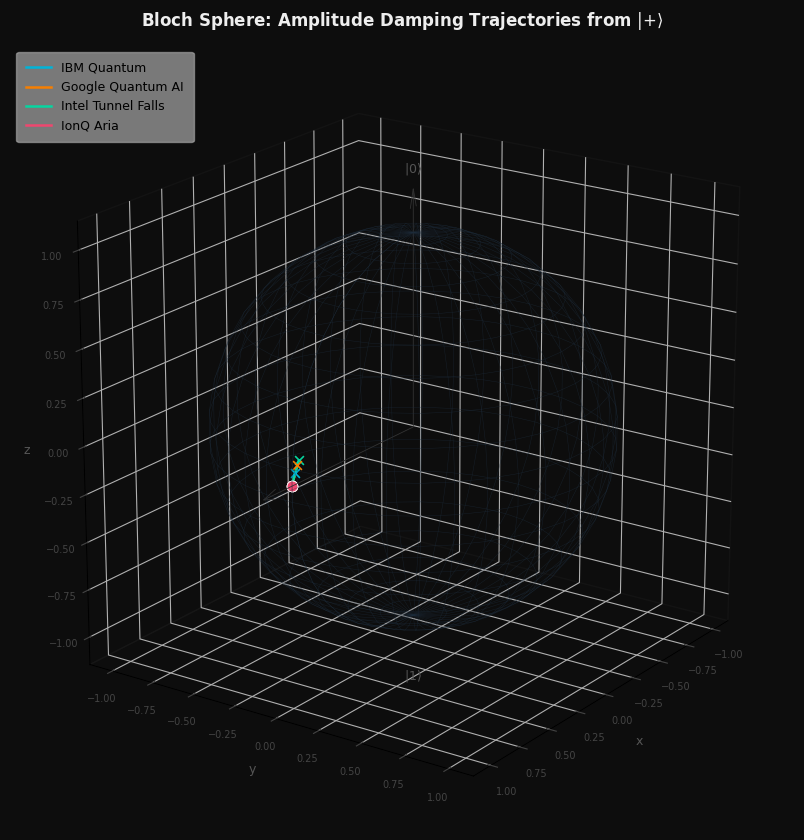

In [7]:
def bloch_vector(rho):
    """Return (x, y, z) Bloch coordinates for a single-qubit density matrix."""
    x = 2.0 * rho[0, 1].real
    y = 2.0 * rho[0, 1].imag
    z = (rho[0, 0] - rho[1, 1]).real
    return x, y, z

K_BLOCH = 120   # enough steps for IonQ to show meaningful motion

bloch_traces = {}
for _, row in df.iterrows():
    gamma_p = row["gamma"]
    rho = rho_plus.copy()
    xs, ys, zs = [], [], []
    for _ in range(K_BLOCH + 1):
        bv = bloch_vector(rho)
        xs.append(bv[0]); ys.append(bv[1]); zs.append(bv[2])
        rho = apply_channel(rho, gamma_p)
    bloch_traces[row["platform"]] = (np.array(xs), np.array(ys), np.array(zs))

# ── Wireframe sphere ──────────────────────────────────────────────────────
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 20)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones(len(u)), np.cos(v))

fig = plt.figure(figsize=(9, 8.5))
fig.patch.set_facecolor("#0d0d0d")
ax3 = fig.add_subplot(111, projection="3d")
ax3.set_facecolor("#0d0d0d")

# Sphere wireframe
ax3.plot_wireframe(xs, ys, zs, color="#1e2e3e", linewidth=0.35, alpha=0.55)

# Axes through origin
for direction, label, offset in [
    ([0, 0, 1.22], [0, 0, -1.25], r"$|0\rangle$"),
    ([1.22, 0, 0], [-1.38, 0, 0], r"$|{+}\rangle$"),
]:
    ax3.quiver(0, 0, 0, *direction[:3], color="#333333",
               linewidth=0.6, arrow_length_ratio=0.08)

# Labels for poles
ax3.text(0, 0, 1.30, r"$|0\rangle$", color="#555555", fontsize=9, ha="center")
ax3.text(0, 0, -1.35, r"$|1\rangle$", color="#555555", fontsize=9, ha="center")

# Platform trajectories
for color, (name, (bx, by, bz)) in zip(PALETTE, bloch_traces.items()):
    label_short = name.split("(")[0].strip()
    ax3.plot(bx, by, bz, color=color, linewidth=1.8, label=label_short, zorder=4)
    # Start marker
    ax3.scatter([bx[0]], [by[0]], [bz[0]],
                color=color, s=60, edgecolors="white", linewidths=0.5, zorder=5)
    # End marker (convergence point)
    ax3.scatter([bx[-1]], [by[-1]], [bz[-1]],
                color=color, s=40, marker="x", linewidths=1.2, zorder=5)

ax3.set_title("Bloch Sphere: Amplitude Damping Trajectories from $|{+}\\rangle$",
              fontsize=12, fontweight="bold", color="#eeeeee", pad=14)
ax3.set_xlabel("x", color="#555555", fontsize=9)
ax3.set_ylabel("y", color="#555555", fontsize=9)
ax3.set_zlabel("z", color="#555555", fontsize=9)
ax3.tick_params(colors="#444444", labelsize=7)
ax3.xaxis.pane.fill = False
ax3.yaxis.pane.fill = False
ax3.zaxis.pane.fill = False
ax3.xaxis.pane.set_edgecolor("#1a1a1a")
ax3.yaxis.pane.set_edgecolor("#1a1a1a")
ax3.zaxis.pane.set_edgecolor("#1a1a1a")
ax3.set_box_aspect([1, 1, 1])
ax3.view_init(elev=20, azim=35)

ax3.legend(loc="upper left", fontsize=9, framealpha=0.45, borderpad=0.8)

plt.tight_layout()
out = os.path.join(FIGURES_DIR, "bloch_convergence.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor="#0d0d0d")
print(f"Saved: {out}")
plt.show()

## 5. PennyLane Cross-Validation

We run a single-qubit PennyLane circuit on `default.mixed` that:

1. Prepares $|+\rangle$ via a Hadamard gate
2. Applies `qml.AmplitudeDamping(gamma, wires=0)` once

The output density matrix is compared against `apply_channel(rho_plus, gamma)` from our Kraus implementation.  Agreement to machine precision confirms both approaches model the same physics.

In [8]:
dev = qml.device("default.mixed", wires=1)

print("PennyLane cross-validation: qml.AmplitudeDamping vs. manual Kraus\n")
print(f"  {'Platform':<35}  {'max |delta|':>14}  {'Status':>6}")
print("  " + "-" * 60)

for color, (_, row) in zip(PALETTE, df.iterrows()):
    gamma_p = float(row["gamma"])

    # ── PennyLane circuit ─────────────────────────────────────────────────
    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)
        qml.AmplitudeDamping(gamma_p, wires=0)
        return qml.density_matrix(wires=0)

    rho_pl = np.array(circuit())

    # ── Manual Kraus ──────────────────────────────────────────────────────
    rho_kraus = apply_channel(rho_plus.copy(), gamma_p)

    delta = np.max(np.abs(rho_pl - rho_kraus))
    status = "PASS" if delta < 1e-10 else "FAIL"
    assert status == "PASS", (
        f"PennyLane mismatch for {row['platform']}: max delta = {delta:.2e}"
    )
    print(f"  {row['platform']:<35}  {delta:>14.2e}  {status:>6}")

print("\nAll platforms: PennyLane density matrix == manual Kraus to < 1e-10")

PennyLane cross-validation: qml.AmplitudeDamping vs. manual Kraus

  Platform                                max |delta|  Status
  ------------------------------------------------------------
  IBM Quantum (Eagle)                        4.88e-15    PASS
  Google Quantum AI (Sycamore)               4.88e-15    PASS
  Intel Tunnel Falls (spin)                  4.88e-15    PASS
  IonQ Aria (trapped ion)                    4.88e-15    PASS

All platforms: PennyLane density matrix == manual Kraus to < 1e-10


## 6. Platform Summary Table

Extended parameter table showing γ and the cumulative excited-state population at representative circuit depths ($k = 1, 10, 100$).  This gives an intuition for how quickly each platform loses fidelity as circuit depth grows.

In [9]:
rows = []
for _, row in df.iterrows():
    g = row["gamma"]
    rows.append({
        "Platform":         row["platform"],
        "T₁ (µs)":         f"{row['T1_us']:,.0f}",
        "t_gate (ns)":     f"{row['t_gate_ns']:,.0f}",
        "T₁ / t_gate":     f"{row['ratio']:,.0f}",
        "γ":               f"{g:.2e}",
        "ρ₁₁ at k=1":     f"{analytical_rho11(1.0, g, 1):.6f}",
        "ρ₁₁ at k=10":    f"{analytical_rho11(1.0, g, 10):.6f}",
        "ρ₁₁ at k=100":   f"{analytical_rho11(1.0, g, 100):.6f}",
    })

summary_df = pd.DataFrame(rows).set_index("Platform")
summary_df

,T₁ (µs),t_gate (ns),T₁ / t_gate,γ,ρ₁₁ at k=1,ρ₁₁ at k=10,ρ₁₁ at k=100
Platform,,,,,,,
IBM Quantum (Eagle),100,50,"2,000",5.00e-04,0.999500,0.995012,0.951229
Google Quantum AI (Sycamore),15,12,"1,250",8.00e-04,0.999200,0.992032,0.923116
Intel Tunnel Falls (spin),"1,000","1,000","1,000",1.00e-03,0.999000,0.990050,0.904837
IonQ Aria (trapped ion),"10,000,000","135,000","74,074",1.35e-05,0.999987,0.999865,0.998651


## Summary

**What was shown:**

| Section | Result |
|---|---|
| Kraus operators | $K_0^\dagger K_0 + K_1^\dagger K_1 = I$ verified numerically |
| γ derivation | Continuous curve placed all four platforms in the linear regime ($\tau \ll 1$) |
| Decay validation | Numerical Kraus iteration matches $\rho_{11}(0)(1-\gamma)^k$ to $< 10^{-12}$ |
| Bloch sphere | All trajectories converge to $|0\rangle$ at rates ordered by γ |
| PennyLane match | `qml.AmplitudeDamping` agrees with manual Kraus to $< 10^{-10}$ |

**Platform ordering by γ (lowest to highest noise per gate layer):**  
IonQ Aria $\ll$ IBM Quantum $<$ Google Sycamore $<$ Intel Tunnel Falls

Notebook 04 builds on this validated noise model to run the full noisy Grover simulation across all four platforms and varying $N$.